# characterisation of in vitro endothelium

In [1]:
here::i_am("revisions/06_endothelium_verification/02_characterisation.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# MOFA factors
args$mofa = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/06_endothelium_verification/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

args$seed = 1234

In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[celltype_v2 %in%  c('Endothelium')]  # Only WT cells for celltype marker search

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [5]:
# Load MOFA
mofa = fread(args$mofa) %>%
    .[match(meta$cell, cell)] %>% 
    as.data.frame() %>% 
    tibble::column_to_rownames('cell') 

# Add factors to SCE object
reducedDim(rna.sce,"mofa") = mofa

In [6]:
set.seed(args$seed)
rna.sce <- runUMAP(rna.sce, dimred="mofa", name = 'UMAP_mofa', n_neighbors = 15, min_dist = 0.3)

In [7]:
to.plot <- reducedDim(rna.sce,"UMAP_mofa") %>% as.data.table %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

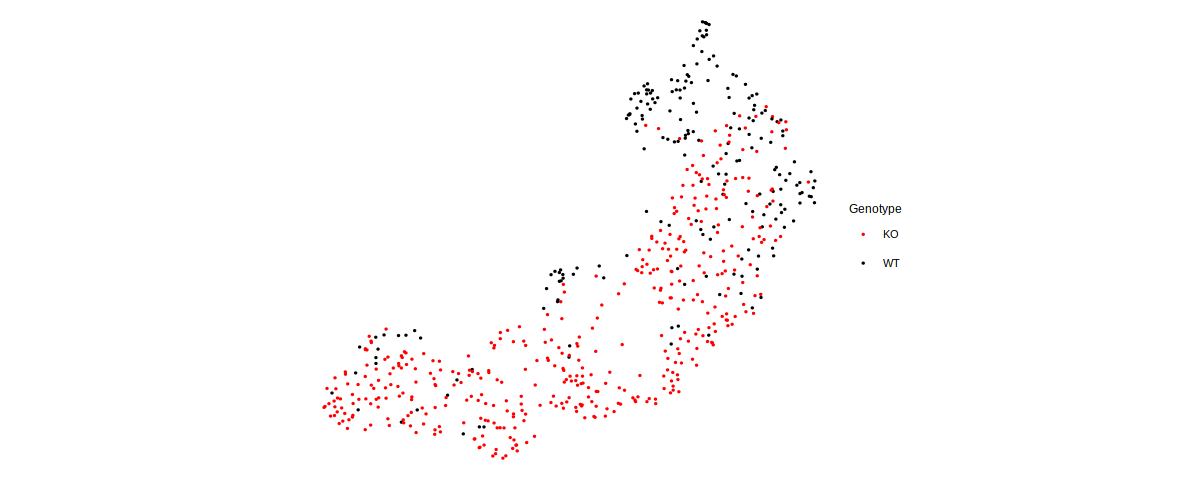

In [8]:
options(repr.plot.height=4, repr.plot.width = 10)
p1 = ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point(size = -0.1) +
    scale_color_manual(values = opts$genotype.colors, name = 'Genotype') + 
    coord_fixed() +
    theme_void() + 
    theme(legend.text = element_text(size = 6, color = 'black'),
          legend.title = element_text(size = 7),
          plot.margin = unit(c(0,0,0,0), 'mm')
          )
p1

In [137]:
ggsave(file.path(args$outdir, 'UMAP_genotype.pdf'), 
       plot = p1 + theme(legend.position = 'none'),
       width = 25, 
       height = 25, 
       units = "mm")

In [9]:
library(Seurat)
seurat = as.Seurat(rna.sce)
set.seed(args$seed)

# Cluster
seurat <- FindNeighbors(seurat, 
                        reduction='mofa',
                        k.param = 20,
                        dims = 1:ncol(reducedDim(rna.sce,"mofa"))
                    )

seurat <- FindClusters(seurat, 
                       resolution = 0.4,  
                       n.start = 10,
                       n.iter = 10)

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Factor to Factor_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to Factor_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from UMAP_mofa_ to UMAPmofa_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to UMAPmofa_”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 637
Number of edges: 21783

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7921
Number of communities: 4
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


In [10]:
reorder_clusters = c(
    '0' = '4',
    '1' = '3',
    '2' = '1',
    '3' = '2'
)
seurat$seurat_clusters = reorder_clusters[match(as.character(seurat$seurat_clusters), names(reorder_clusters))]


In [11]:
to.plot <- reducedDim(rna.sce,"UMAP_mofa") %>% as.data.table %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

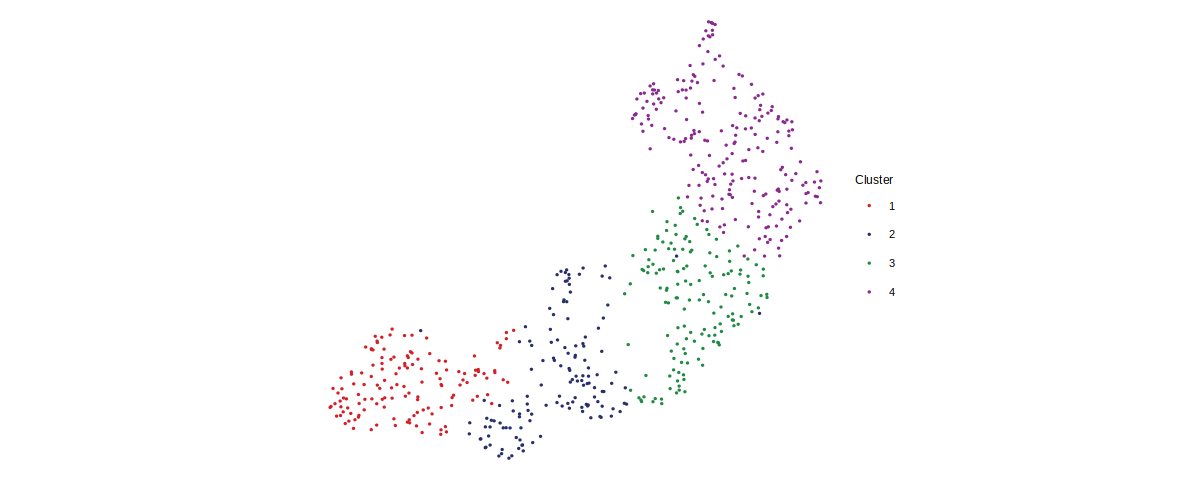

In [12]:
to.plot$seurat_clusters = seurat@meta.data$seurat_clusters

options(repr.plot.height=4, repr.plot.width = 10)
p2 = ggplot(to.plot, aes(V1, V2, color = seurat_clusters)) + 
    geom_point(size = -0.1) + 
    scale_color_manual(values = ArchRPalettes$stallion2, name = 'Cluster') + 
    coord_fixed() +
    theme_void() + 
    theme(legend.text = element_text(size = 6, color = 'black'),
          legend.title = element_text(size = 7),
          plot.margin = unit(c(0,0,0,0), 'mm')
          )
p2

In [142]:
ggsave(file.path(args$outdir, 'UMAP_clusters.pdf'), 
       plot = p2 + theme(legend.position = 'none'),
       width = 25, 
       height = 25, 
       units = "mm")

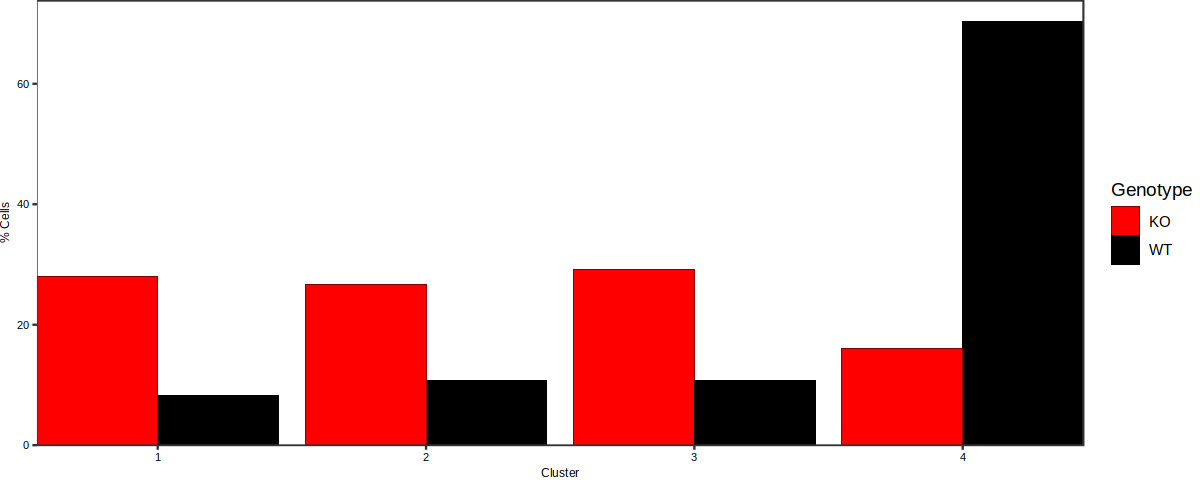

In [13]:
to.plot_proportions = to.plot %>% copy() %>%
    .[, Ntot := .N, by = 'genotype'] %>%
    .[, prop := .N/Ntot*100, by = c('genotype', 'seurat_clusters')] %>%
    unique(by = c('genotype', 'seurat_clusters'))

p3 = ggplot(to.plot_proportions, aes(as.character(as.numeric(seurat_clusters)), prop, fill = genotype)) + 
    geom_bar(stat = 'identity', position = 'dodge', color = 'black', linewidth = 0.1) + 
    scale_fill_manual(values = opts$genotype.colors, name = 'Genotype') + 
    ylab('% Cells') + xlab('Cluster') + 
    scale_x_discrete(expand = c(0,0)) + 
    scale_y_continuous(expand = c(0,0, 0.05, 0)) + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black', size = 6),
          axis.title = element_text(size = 7),
          plot.title = element_text(size = 8),
          panel.grid = element_blank(),
          plot.margin = unit(c(0,0,0,0), 'mm')
         )
p3

In [154]:
ggsave(file.path(args$outdir, 'clusters_cellcounts.pdf'), 
       plot = p3 + theme(legend.position = 'none'),
       width = 35, 
       height = 25, 
       units = "mm")

In [15]:
seurat$cluster_genotype = paste0(as.numeric(seurat$seurat_clusters), ': ', gsub('KO', 'KD', seurat$genotype))

character(0)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.
Warning message:
“Removed 31 rows containing missing values (`geom_point()`).”


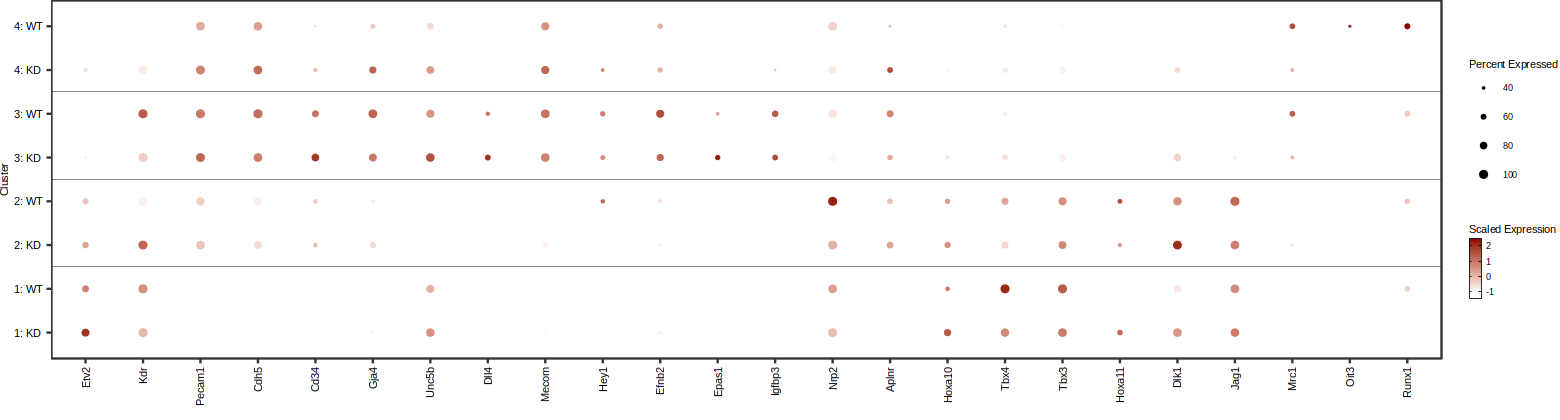

In [19]:
# features = c(
#     'Etv2', 'Kdr', # Immature endothelium
#     'Pecam1','Cdh5','Cd34', # Pan-endo
#     'Gja4', 'Unc5b', 'Dll4', 'Mecom', 'Hey1', 'Efnb2', 'Epas1', 'Cxcr4', 'Igfbp3', # Arterial
#     'Nr2f2', 'Nrp2', 'Aplnr', # Venous
#     'Hoxa10', 'Tbx4', 'Tbx3', 'Hoxa11', 'Dlk1', 'Jag1', # Allantois
#     'Lyve1', 'Stab2', 'Mrc1', 'Oit3',  # Yolk-sac
#     'Runx1' # Hemogenic
# )

features = c(
    'Etv2', 'Kdr', # Immature endothelium
    'Pecam1','Cdh5','Cd34', # Pan-endo
    'Gja4', 'Unc5b', 'Dll4', 'Mecom', 'Hey1', 'Efnb2', 'Epas1', 'Igfbp3', # Arterial
    'Nrp2', 'Aplnr', # Venous
    'Hoxa10', 'Tbx4', 'Tbx3', 'Hoxa11', 'Dlk1', 'Jag1', # Allantois
    'Mrc1', 'Oit3',  # Yolk-sac
    'Runx1' # Hemogenic
)

features[!features %in% rownames(rna.sce)]

options(repr.plot.width = 13, repr.plot.height = 3.5)
p4 = DotPlot(seurat, 
        features = unique(features), 
        group.by = 'cluster_genotype',
        scale = T,
        dot.min = 0.2) + 
    scale_color_gradientn(colours = c('white', 'white', 'darkred'), values = c(0, 0.1, 1), name='Scaled Expression') + 
    RotatedAxis() +
    scale_size_continuous(range = c(-1.5, 1.5), breaks = c(20, 40, 60, 80, 100), ) + 
    geom_hline(yintercept = c(2.5, 4.5, 6.5), linewidth = 0.1) + 
    ylab('Cluster') + xlab('') +
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    theme_bw() +
    theme(text=element_text(size=6, color = 'black'), 
         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=6, color = 'black'), 
         axis.text.y=element_text(hjust=0, size=6, color = 'black'),
         panel.grid = element_blank(),
          plot.margin = unit(c(0,0,0,0), 'mm'))
p4

In [20]:
ggsave(file.path(args$outdir, 'dotplot.pdf'), 
       plot = p4 + theme(legend.position = 'none'),
       width = 95, 
       height = 35, 
       units = "mm")

Warning message:
“Removed 31 rows containing missing values (`geom_point()`).”


Warning message:
“Removed 31 rows containing missing values (`geom_point()`).”


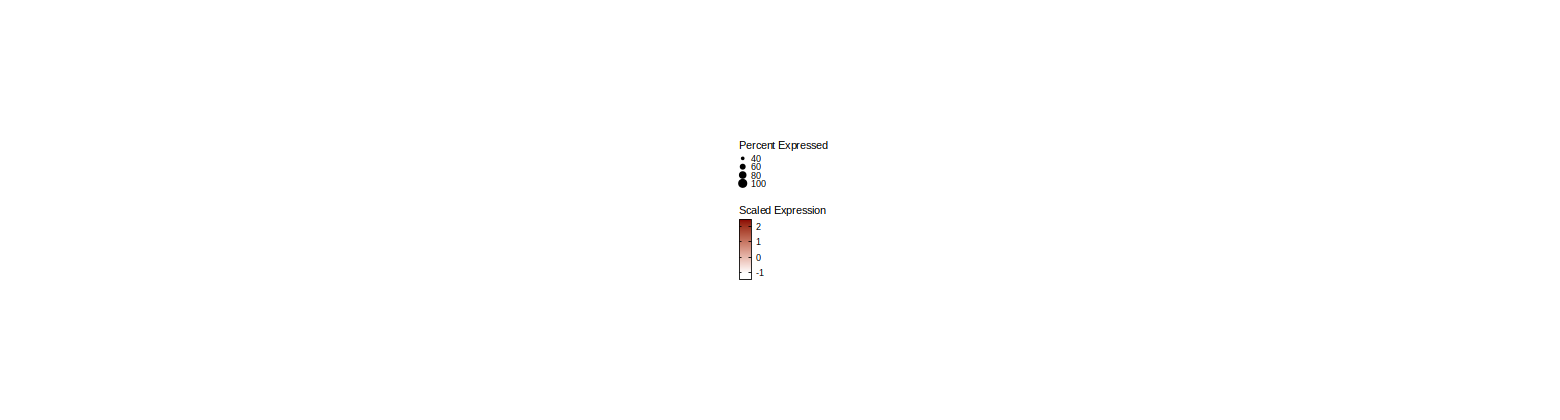

In [21]:
celltype_legend = as_ggplot(get_legend(p4 + theme(legend.key.size  = unit(0, "pt"),
                                                  legend.margin=margin(0,0,0,0))))

celltype_legend
ggsave(file.path(args$outdir, 'dotplot_legend.pdf'), 
       plot = celltype_legend,
       width = 20, 
       height = 35, 
       units = "mm")

In [44]:
# Violin plots 

features = c(
    'Etv2', 'Kdr', # Immature endothelium
    'Pecam1','Cdh5','Cd34', # Pan-endo
    'Hoxa10', 'Tbx4', 'Tbx3', 'Hoxa11', 'Dlk1', 'Jag1', 'Cldn5', # Allantois
    'Gja4', 'Gja5', 'Unc5b', 'Dll4', 'Mecom', 'Hey1', 'Efnb2', 'Epas1', 'Cxcr4', 'Igfbp3', # Arterial
    'Nr2f2', 'Nrp2', 'Aplnr', 'Flrt2', # Venous
    'Lyve1', 'Stab2', 'Mrc1', 'Oit3', 'Runx1', # Yolk-sac
    'Cd24a', 'Gpc3', # Embryo proper
    'Bnip3', 'Cyp26a1', 'Cd44',  'Gfi1', 'Ltbp4', 'Eln', 'Fbln5', 'Ptp4a3', 'Kitl', 'Prdm1', 'Nid2', 'Vwa1' # Others
)

features[!features %in% rownames(rna.sce)]

meta_tmp = as.data.table(to.plot, keep.rownames = T) %>% 
    .[,.(cell, seurat_clusters, genotype, UMAP1, UMAP2)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(rna.sce[x,meta_tmp$cell]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

character(0)

In [14]:
# ggplot(expr[gene == 'Runx1'], aes(UMAP1, UMAP2, color = expression)) +
#     geom_point() + 
#     facet_wrap(~genotype)

In [45]:
# Violin plots 

meta_tmp = as.data.table(to.plot, keep.rownames = T) %>% 
    .[,.(cell, seurat_clusters, genotype)]

expr = mclapply(features, function(x){
    tmp = cbind(meta_tmp, 
                data.table(gene = x,
                           expression = as.numeric(logcounts(rna.sce[x,meta_tmp$cell]))
                          )
               )
    return(tmp)
    
}, mc.cores = 32) %>% rbindlist() %>% 
    .[, expression_minmax := minmax.normalisation(expression), by = 'gene']

In [46]:
expr_dotplot = expr %>% copy() %>%
    .[, expression_scaled := scale(expression, center = T, scale = T), by = 'gene'] %>%
    .[,':='(mean = mean(expression),
            mean_scaled = mean(expression_scaled),
            perc = mean(expression > 0)),
     by = c('gene','seurat_clusters', 'genotype')] %>%
    unique(by = c('gene','seurat_clusters', 'genotype')) %>%
    .[, cluster_genotype := paste0(seurat_clusters, '_', genotype)] %>%
    .[, gene := factor(gene, levels = features)]

In [47]:
summary(expr_dotplot$mean)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.1216  0.5477  0.9003  1.2139  4.5490 

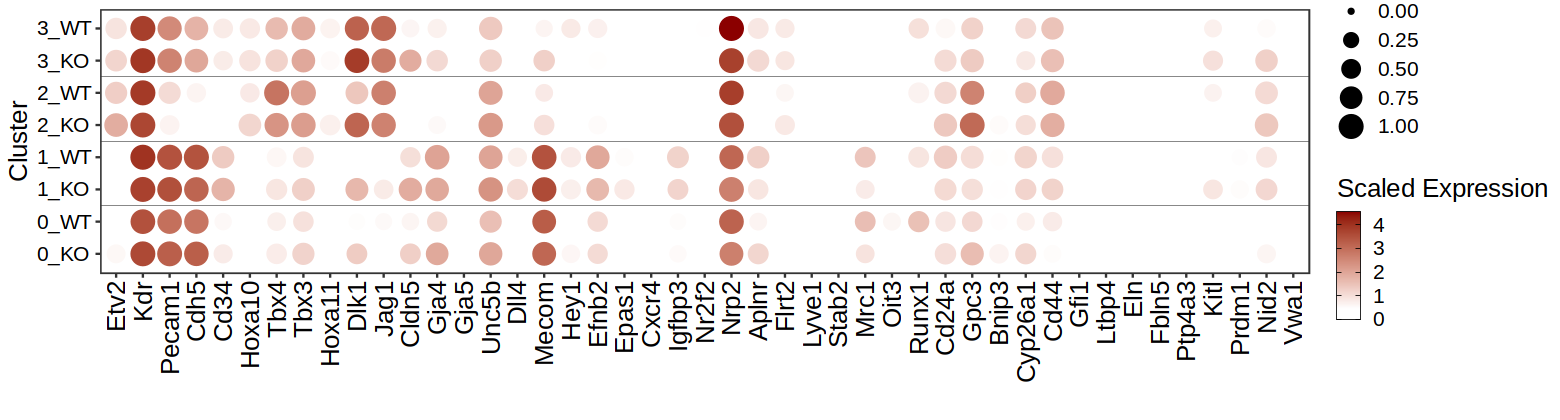

In [48]:
options(repr.plot.width = 13, repr.plot.height = 3.5)

ggplot(expr_dotplot, aes(gene, cluster_genotype, size = perc, color = mean)) + 
    geom_point() + 
    scale_color_gradientn(colours = c('white', 'white', 'darkred'), values = c(0, 0.1, 1), name='Scaled Expression') + 
    RotatedAxis() +
    geom_hline(yintercept = c(2.5, 4.5, 6.5), linewidth = 0.1) + 
    ylab('Cluster') + xlab('') +
    guides(colour = guide_colourbar(
         barwidth = 1, barheight = 4.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    theme_bw() +
    theme(text=element_text(size=15, color = 'black'), 
         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=15, color = 'black'), 
         axis.text.y=element_text(hjust=0, color = 'black'),
         panel.grid = element_blank())

Warning message:
“Removed 126 rows containing missing values (`geom_point()`).”


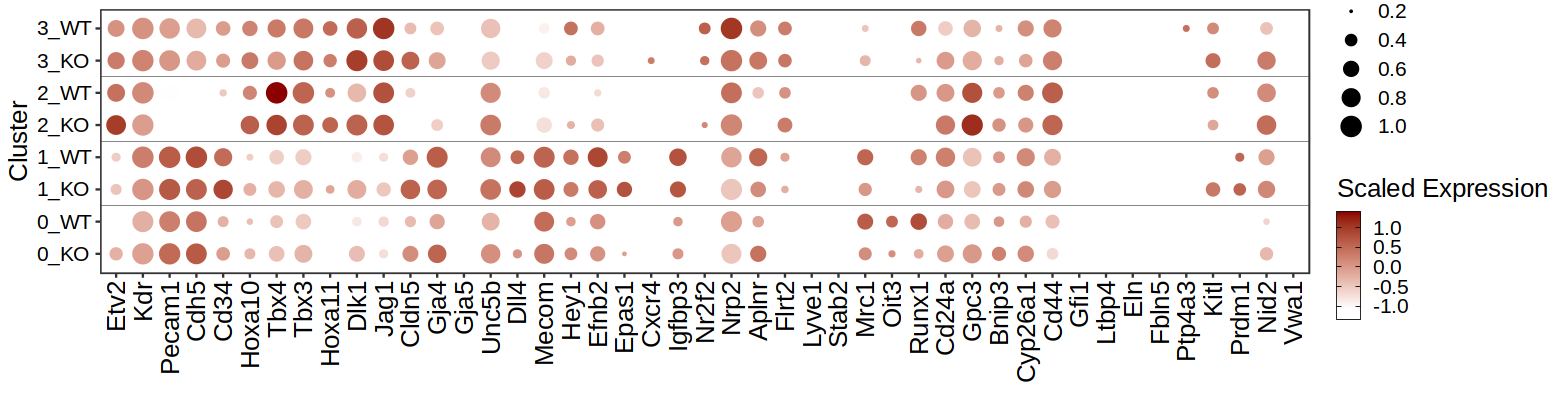

In [65]:
options(repr.plot.width = 13, repr.plot.height = 3.5)

ggplot(expr_dotplot, aes(gene, cluster_genotype, size = perc, color = mean_scaled)) + 
    geom_point() + 
    scale_color_gradientn(colours = c('white', 'white', 'darkred'), values = c(0, 0.1, 1), name='Scaled Expression') + 
    scale_size(limits = c(0.2, 1), range = c(0, 5)) + 
    RotatedAxis() +
    geom_hline(yintercept = c(2.5, 4.5, 6.5), linewidth = 0.1) + 
    ylab('Cluster') + xlab('') +
    guides(colour = guide_colourbar(
         barwidth = 1, barheight = 4.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    theme_bw() +
    theme(text=element_text(size=15, color = 'black'), 
         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=15, color = 'black'), 
         axis.text.y=element_text(hjust=0, color = 'black'),
         panel.grid = element_blank())

In [56]:
expr_dotplot = expr_dotplot[, scaled_group_mean := scale(mean), by = 'gene']

Warning message:
“Removed 126 rows containing missing values (`geom_point()`).”


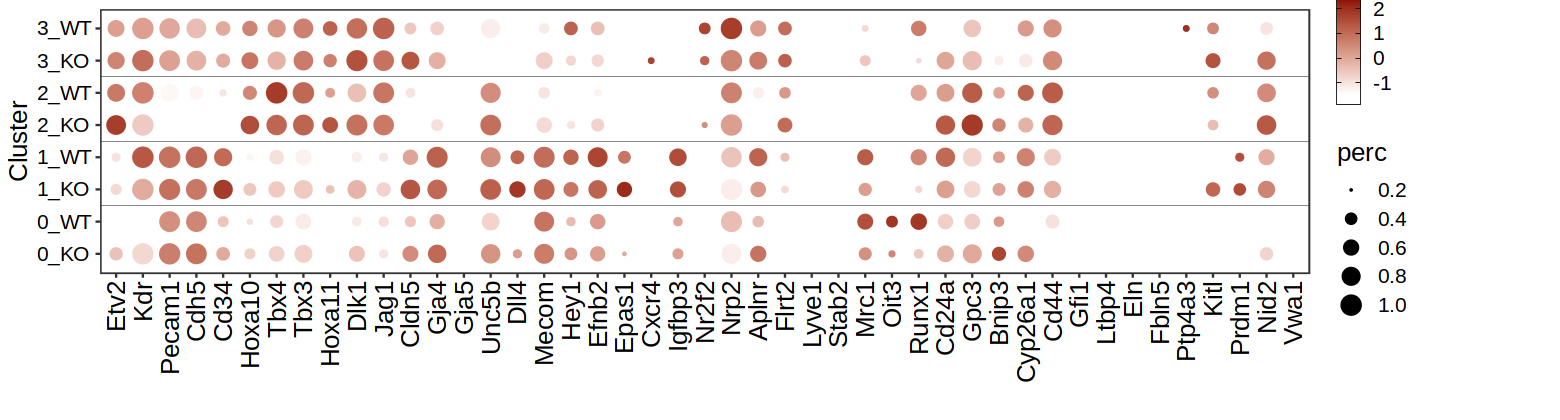

In [64]:
options(repr.plot.width = 13, repr.plot.height = 3.5)

ggplot(expr_dotplot, aes(gene, cluster_genotype, size = perc, color = scaled_group_mean)) + 
    geom_point() + 
    scale_color_gradientn(colours = c('white', 'white', 'darkred'), values = c(0, 0.1, 1), name='Scaled Expression') + 
    scale_size(limits = c(0.2, 1), range = c(0, 5)) + 
    RotatedAxis() +
    geom_hline(yintercept = c(2.5, 4.5, 6.5), linewidth = 0.1) + 
    ylab('Cluster') + xlab('') +
    guides(colour = guide_colourbar(
         barwidth = 1, barheight = 4.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    theme_bw() +
    theme(text=element_text(size=15, color = 'black'), 
         axis.text.x=element_text(angle=90,hjust=1,vjust=0.5, size=15, color = 'black'), 
         axis.text.y=element_text(hjust=0, color = 'black'),
         panel.grid = element_blank())